# CSE 445 — Assignment 1 — Notebook 3: YOLOv12 Training, Evaluation & Error Analysis
Group: J
Members: 1.Farha Anjum Afia, 2022-3-60-237
         2.Rukaiah Bintay Morshed, 2022-3-60-334
         3.Kaniz Reza Mithila, 2022-3-60-052
         4.Redwan Ahmed, 2022-3-60-155
Dataset: Dental OPG Object Detection Dataset (same corrected/split version as Notebook 1)
Model: YOLOv12-m

Cell 2 — CONFIG:

In [1]:
CONFIG = {
    'model_variant': 'yolo12m.pt',
    'model_size_justification': (
        "Identical to Notebook 2 (YOLOv10-m) deliberately — same size, epochs, and "
        "hyperparameters across all YOLO variants isolates architecture as the only "
        "variable, keeping the v10/v12/v26 comparison fair and interpretable."
    ),
    'epochs': 50,
    'imgsz': 640,
    'batch': 16,
    'optimizer': 'SGD',
    'lr0': 0.01,
    'cos_lr': True,
    'warmup_epochs': 3,
    'patience': 50,

    'hsv_h': 0.0, 'hsv_s': 0.0, 'hsv_v': 0.4,
    'fliplr': 0.5, 'flipud': 0.0, 'degrees': 10,
    'translate': 0.1, 'scale': 0.3,
    'mosaic': 1.0, 'close_mosaic': 10,
    'overlap_mask': True, 'copy_paste': 0.0,

    'iou': 0.6,
    'conf': 0.25,
}
print("YOLOv12 CONFIG set (identical to YOLOv10 except model_variant — intentional):")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

YOLOv12 CONFIG set (identical to YOLOv10 except model_variant — intentional):
  model_variant: yolo12m.pt
  model_size_justification: Identical to Notebook 2 (YOLOv10-m) deliberately — same size, epochs, and hyperparameters across all YOLO variants isolates architecture as the only variable, keeping the v10/v12/v26 comparison fair and interpretable.
  epochs: 50
  imgsz: 640
  batch: 16
  optimizer: SGD
  lr0: 0.01
  cos_lr: True
  warmup_epochs: 3
  patience: 50
  hsv_h: 0.0
  hsv_s: 0.0
  hsv_v: 0.4
  fliplr: 0.5
  flipud: 0.0
  degrees: 10
  translate: 0.1
  scale: 0.3
  mosaic: 1.0
  close_mosaic: 10
  overlap_mask: True
  copy_paste: 0.0
  iou: 0.6
  conf: 0.25


Environment + dataset setup:

In [2]:
!pip install ultralytics -q

import torch, os, shutil, zipfile, yaml
from pathlib import Path

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

DETECTION_ROOT = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'data.yaml' in files:
        DETECTION_ROOT = root
        break
print("Detected shared dataset root:", DETECTION_ROOT)

WORK_DIR = Path('/kaggle/working/dental_final')
for s in ['train', 'val', 'test']:
    img_out, lbl_out = WORK_DIR / s / 'images', WORK_DIR / s / 'labels'
    img_out.mkdir(parents=True, exist_ok=True)

    zip_path = Path(DETECTION_ROOT) / f'{s}_images.zip'
    extracted_dir = Path(DETECTION_ROOT) / f'{s}_images'
    if zip_path.exists():
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(img_out)
    elif extracted_dir.exists():
        for f in extracted_dir.glob('*.jpg'):
            shutil.copy2(f, img_out / f.name)

    shutil.copytree(Path(DETECTION_ROOT) / s / 'labels', lbl_out, dirs_exist_ok=True)
    print(f"{s}: {len(list(img_out.glob('*.jpg')))} images, {len(list(lbl_out.glob('*.txt')))} labels")

with open(Path(DETECTION_ROOT) / 'data.yaml') as f:
    src_yaml = yaml.safe_load(f)
final_yaml = {
    'train': str(WORK_DIR / 'train' / 'images'),
    'val': str(WORK_DIR / 'val' / 'images'),
    'test': str(WORK_DIR / 'test' / 'images'),
    'nc': src_yaml['nc'], 'names': src_yaml['names'],
}
with open(WORK_DIR / 'data.yaml', 'w') as f:
    yaml.dump(final_yaml, f)
print("data.yaml ready at:", WORK_DIR / 'data.yaml')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 22.8 MB/s eta 0:00:00a 0:00:01
GPU available: True
GPU name: Tesla T4
Detected shared dataset root: /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final
train: 7998 images, 7998 labels
val: 993 images, 993 labels
test: 1009 images, 1009 labels
data.yaml ready at: /kaggle/working/dental_final/data.yaml


-epoch dry run:

In [3]:
from ultralytics import YOLO
import time

model = YOLO(CONFIG['model_variant'])   # if this errors, tell me the exact message — this is the YOLOv12-stability check

start = time.time()
dry_run_results = model.train(
    data=str(WORK_DIR / 'data.yaml'),
    epochs=1,
    imgsz=CONFIG['imgsz'], batch=CONFIG['batch'],
    optimizer=CONFIG['optimizer'], lr0=CONFIG['lr0'], cos_lr=CONFIG['cos_lr'],
    warmup_epochs=CONFIG['warmup_epochs'],
    hsv_h=CONFIG['hsv_h'], hsv_s=CONFIG['hsv_s'], hsv_v=CONFIG['hsv_v'],
    fliplr=CONFIG['fliplr'], flipud=CONFIG['flipud'], degrees=CONFIG['degrees'],
    translate=CONFIG['translate'], scale=CONFIG['scale'],
    mosaic=CONFIG['mosaic'], close_mosaic=CONFIG['close_mosaic'],
    overlap_mask=CONFIG['overlap_mask'], copy_paste=CONFIG['copy_paste'],
    project='/kaggle/working/yolov12m_dental', name='dry_run', exist_ok=True,
)
elapsed_min = (time.time() - start) / 60
print(f"\n1-epoch time: {elapsed_min:.1f} minutes")
print(f"Estimated total for 50 epochs: {elapsed_min * 50 / 60:.1f} hours")
print(f"Fits within ~8h budget: {elapsed_min * 50 / 60 < 8}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.92 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/dental_final/data.yaml, degrees=10, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=1, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hs

full training run + loss/mAP curves:

In [ ]:
model_full = YOLO(CONFIG['model_variant'])  # fresh pretrained weights, not the dry-run's

full_results = model_full.train(
    data=str(WORK_DIR / 'data.yaml'),
    epochs=CONFIG['epochs'],
    imgsz=CONFIG['imgsz'],
    batch=CONFIG['batch'],
    optimizer=CONFIG['optimizer'],
    lr0=CONFIG['lr0'],
    cos_lr=CONFIG['cos_lr'],
    warmup_epochs=CONFIG['warmup_epochs'],
    patience=CONFIG['patience'],
    hsv_h=CONFIG['hsv_h'], hsv_s=CONFIG['hsv_s'], hsv_v=CONFIG['hsv_v'],
    fliplr=CONFIG['fliplr'], flipud=CONFIG['flipud'], degrees=CONFIG['degrees'],
    translate=CONFIG['translate'], scale=CONFIG['scale'],
    mosaic=CONFIG['mosaic'], close_mosaic=CONFIG['close_mosaic'],
    overlap_mask=CONFIG['overlap_mask'], copy_paste=CONFIG['copy_paste'],
    project='/kaggle/working/yolov12m_dental',
    name='full_run',
    exist_ok=True,
)

import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv('/kaggle/working/yolov12m_dental/full_run/results.csv')
results_df.columns = results_df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(results_df['epoch'], results_df['train/box_loss'], label='train box loss')
axes[0].plot(results_df['epoch'], results_df['val/box_loss'], label='val box loss')
axes[0].plot(results_df['epoch'], results_df['train/cls_loss'], label='train cls loss', linestyle='--')
axes[0].plot(results_df['epoch'], results_df['val/cls_loss'], label='val cls loss', linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_title('Loss curves'); axes[0].legend()

axes[1].plot(results_df['epoch'], results_df['metrics/mAP50(B)'], label='mAP@50')
axes[1].plot(results_df['epoch'], results_df['metrics/mAP50-95(B)'], label='mAP@50-95')
axes[1].set_xlabel('Epoch'); axes[1].set_title('Validation mAP'); axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/yolov12m_dental/full_run/curves_summary.png', dpi=120)
plt.show()

In [3]:
DETECTION_ROOT = None
FULL_RUN_CKPT = None

for root, dirs, files in os.walk('/kaggle/input'):
    if 'data.yaml' in files:
        has_real_images = any(
            (Path(root) / f'{s}_images.zip').exists() or (Path(root) / f'{s}_images').exists()
            for s in ['train', 'val', 'test']
        )
        if has_real_images:
            DETECTION_ROOT = root
    if 'best.pt' in files and 'full_run' in root:
        FULL_RUN_CKPT = os.path.join(root, 'best.pt')

print("Team dataset (verified real):", DETECTION_ROOT)
print("YOLOv12 checkpoint:", FULL_RUN_CKPT)
assert DETECTION_ROOT is not None, "Real team dataset not found — check it's attached"
assert FULL_RUN_CKPT is not None, "Checkpoint not found"

Team dataset (verified real): /kaggle/input/datasets/redwanahmed2025/dental-detection-final-v3/dental_final
YOLOv12 checkpoint: /kaggle/input/datasets/farhaanjumnisha/yolov12-checkpoint/yolov12m_dental/full_run/weights/best.pt


In [5]:
import os

print("=== Everything under /kaggle/input/datasets (each folder = one attached dataset) ===")
for item in os.listdir('/kaggle/input/datasets'):
    print(" ", item)

=== Everything under /kaggle/input/datasets (each folder = one attached dataset) ===
  redwanahmed2025
  farhaanjumnisha


In [9]:
!pip install ultralytics -q
import shutil, zipfile, yaml
from pathlib import Path

WORK_DIR = Path('/kaggle/working/dental_final')
for s in ['train', 'val', 'test']:
    img_out, lbl_out = WORK_DIR / s / 'images', WORK_DIR / s / 'labels'
    img_out.mkdir(parents=True, exist_ok=True)
    zip_path = Path(DETECTION_ROOT) / f'{s}_images.zip'
    extracted_dir = Path(DETECTION_ROOT) / f'{s}_images'
    if zip_path.exists():
        with zipfile.ZipFile(zip_path) as zf: zf.extractall(img_out)
    elif extracted_dir.exists():
        for f in extracted_dir.glob('*.jpg'): shutil.copy2(f, img_out / f.name)
    shutil.copytree(Path(DETECTION_ROOT) / s / 'labels', lbl_out, dirs_exist_ok=True)
    print(f"{s}: {len(list(img_out.glob('*.jpg')))} images, {len(list(lbl_out.glob('*.txt')))} labels")

with open(Path(DETECTION_ROOT) / 'data.yaml') as f:
    src_yaml = yaml.safe_load(f)
final_yaml = {
    'train': str(WORK_DIR / 'train' / 'images'), 'val': str(WORK_DIR / 'val' / 'images'),
    'test': str(WORK_DIR / 'test' / 'images'), 'nc': src_yaml['nc'], 'names': src_yaml['names'],
}
with open(WORK_DIR / 'data.yaml', 'w') as f:
    yaml.dump(final_yaml, f)
CLASS_NAMES = src_yaml['names']
print("\ndata.yaml ready. Classes:", CLASS_NAMES)

train: 7998 images, 7998 labels
val: 993 images, 993 labels
test: 1009 images, 1009 labels

data.yaml ready. Classes: ['Cavities', 'Damage', 'Infection', 'Wisdom']


test-split evaluation

In [10]:
from ultralytics import YOLO

print("Loading checkpoint from:", FULL_RUN_CKPT)
model = YOLO(FULL_RUN_CKPT)

test_results = model.val(
    data=str(WORK_DIR / 'data.yaml'),
    split='test',
    imgsz=640, batch=16,
    conf=0.25, iou=0.6,
)

precision_final = test_results.box.mp
recall_final = test_results.box.mr
f1_final = 2 * precision_final * recall_final / (precision_final + recall_final) if (precision_final + recall_final) > 0 else 0
inference_ms = test_results.speed['inference']

print("\n=== Overall test-split metrics ===")
print(f"Precision: {precision_final:.3f} | Recall: {recall_final:.3f} | F1: {f1_final:.3f}")
print(f"mAP@50: {test_results.box.map50:.3f} | mAP@50-95: {test_results.box.map:.3f}")
print(f"Inference speed: {inference_ms:.2f} ms/image -> FPS: {1000/inference_ms:.1f}")

print("\n=== Per-class metrics ===")
for i, name in enumerate(CLASS_NAMES):
    p_c, r_c = test_results.box.p[i], test_results.box.r[i]
    f1_c = 2 * p_c * r_c / (p_c + r_c) if (p_c + r_c) > 0 else 0
    print(f"{name:12s} P={p_c:.3f} R={r_c:.3f} F1={f1_c:.3f} mAP50={test_results.box.ap50[i]:.3f} mAP50-95={test_results.box.ap[i]:.3f}")

Loading checkpoint from: /kaggle/input/datasets/farhaanjumnisha/yolov12-checkpoint/yolov12m_dental/full_run/weights/best.pt
Ultralytics 8.4.93 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLOv12m summary (fused): 169 layers, 20,107,996 parameters, 0 gradients, 67.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1201.7±294.6 MB/s, size: 39.1 KB)
val: Scanning /kaggle/working/dental_final/test/labels... 1009 images, 18 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1009/1009 1.3Kit/s 0.8s0.0s
val: New cache created: /kaggle/working/dental_final/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 64/64 1.4it/s 46.6s0.7ss
                   all       1009       2520      0.655      0.572      0.481      0.226
              Cavities        315        680       0.63      0.481      0.389      0.157
                Damage        354       1119      0.577      0.498      0.348       0.13
        

error analysis

In [11]:
import numpy as np
import pandas as pd

test_img_dir = WORK_DIR / 'test' / 'images'
test_lbl_dir = WORK_DIR / 'test' / 'labels'

def load_gt_boxes(label_path):
    if not label_path.exists() or label_path.stat().st_size == 0:
        return np.zeros((0, 5))
    lines = label_path.read_text().strip().split('\n')
    boxes = []
    for line in lines:
        parts = line.split()
        boxes.append([int(parts[0])] + [float(x) for x in parts[1:5]])
    return np.array(boxes)

def iou_xywh(box1, box2):
    def to_xyxy(b):
        x, y, w, h = b
        return [x - w/2, y - h/2, x + w/2, y + h/2]
    b1, b2 = to_xyxy(box1), to_xyxy(box2)
    xi1, yi1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    xi2, yi2 = min(b1[2], b2[2]), min(b1[3], b2[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area1 = (b1[2]-b1[0]) * (b1[3]-b1[1])
    area2 = (b2[2]-b2[0]) * (b2[3]-b2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

false_negatives, false_positives, misclassifications = [], [], []
IOU_THRESH = 0.5

detections = model.predict(source=str(test_img_dir), conf=0.25, iou=0.6, imgsz=640, verbose=False)

for det in detections:
    img_id = Path(det.path).stem
    gt = load_gt_boxes(test_lbl_dir / f'{img_id}.txt')
    preds = det.boxes.xywhn.cpu().numpy() if len(det.boxes) else np.zeros((0, 4))
    pred_cls = det.boxes.cls.cpu().numpy() if len(det.boxes) else np.zeros((0,))
    pred_conf = det.boxes.conf.cpu().numpy() if len(det.boxes) else np.zeros((0,))

    matched_gt, matched_pred = set(), set()

    for gi, g in enumerate(gt):
        best_iou, best_pi = 0, -1
        for pi, pbox in enumerate(preds):
            if pi in matched_pred:
                continue
            iou = iou_xywh(g[1:], pbox)
            if iou > best_iou:
                best_iou, best_pi = iou, pi
        if best_iou >= IOU_THRESH:
            matched_gt.add(gi); matched_pred.add(best_pi)
            if int(pred_cls[best_pi]) != int(g[0]):
                misclassifications.append({'image_id': img_id, 'true_class': CLASS_NAMES[int(g[0])],
                                            'pred_class': CLASS_NAMES[int(pred_cls[best_pi])],
                                            'iou': best_iou, 'pred_box': preds[best_pi], 'true_box': g[1:]})

    for gi, g in enumerate(gt):
        if gi not in matched_gt:
            false_negatives.append({'image_id': img_id, 'true_class': CLASS_NAMES[int(g[0])], 'box': g[1:]})
    for pi, pbox in enumerate(preds):
        if pi not in matched_pred:
            false_positives.append({'image_id': img_id, 'pred_class': CLASS_NAMES[int(pred_cls[pi])],
                                      'conf': pred_conf[pi], 'box': pbox})

print(f"Total false negatives: {len(false_negatives)}")
print(f"Total false positives: {len(false_positives)}")
print(f"Total misclassifications: {len(misclassifications)}")

print("\nFalse negatives by class:")
print(pd.DataFrame(false_negatives)['true_class'].value_counts())
print("\nFalse positives by class:")
print(pd.DataFrame(false_positives)['pred_class'].value_counts())
if misclassifications:
    print("\nConfusion pairs:")
    print(pd.DataFrame(misclassifications).groupby(['true_class','pred_class']).size().sort_values(ascending=False))

WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

Total false negatives: 1242
Total false positives: 780
Total misclassifications: 30

False negatives by class:
true_class
Damage       636
Cavities     338
Infection    242
Wisdom        26
Name: count, dtype: int64

False positives by class:
pred_class
Damage       364
Cavities     269
Infection     89
Wisdom        58
Name: count, dtype: int64

Confusion pairs:
true_class  pred_class
Damage      Cavities      19
Cavities    Damage         5
Damage      

visualize a few actual examples

=== False Negatives ===


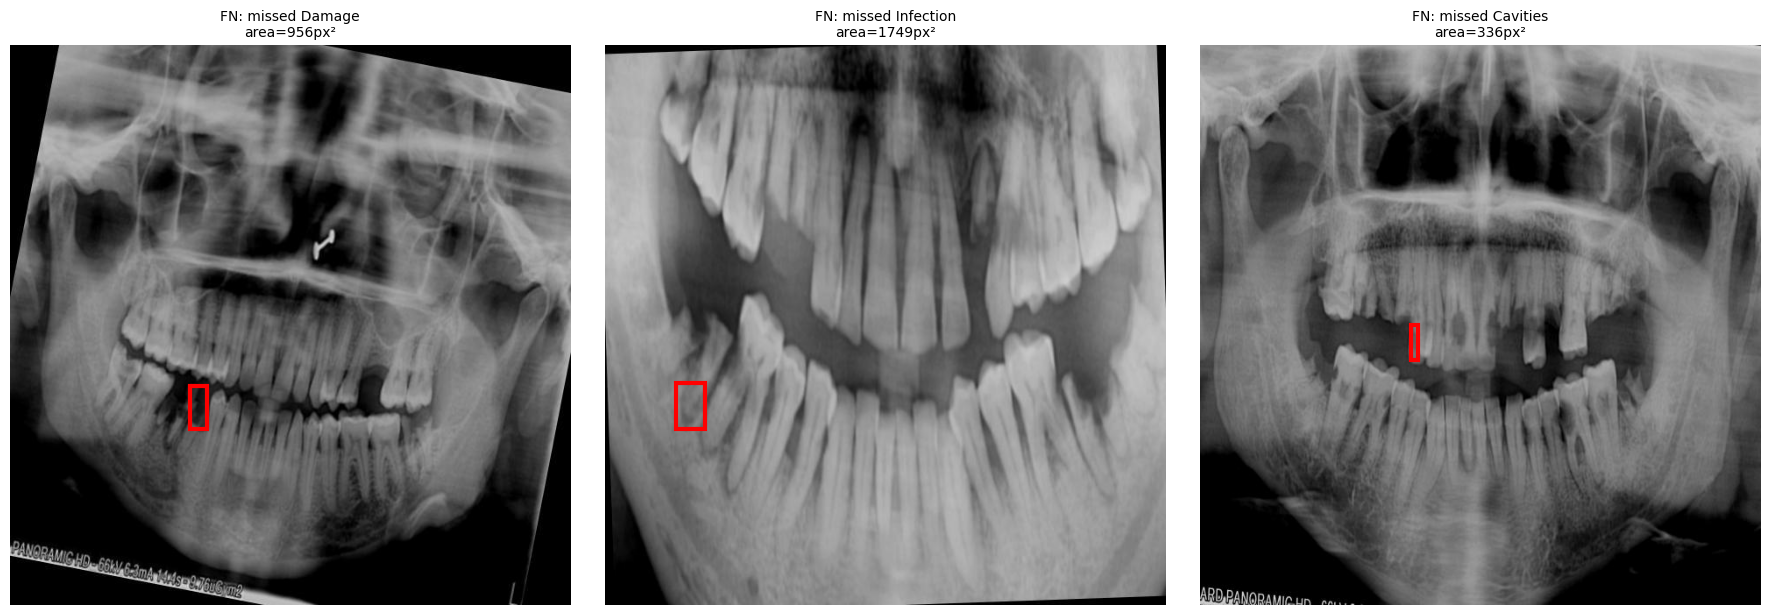

=== False Positives ===


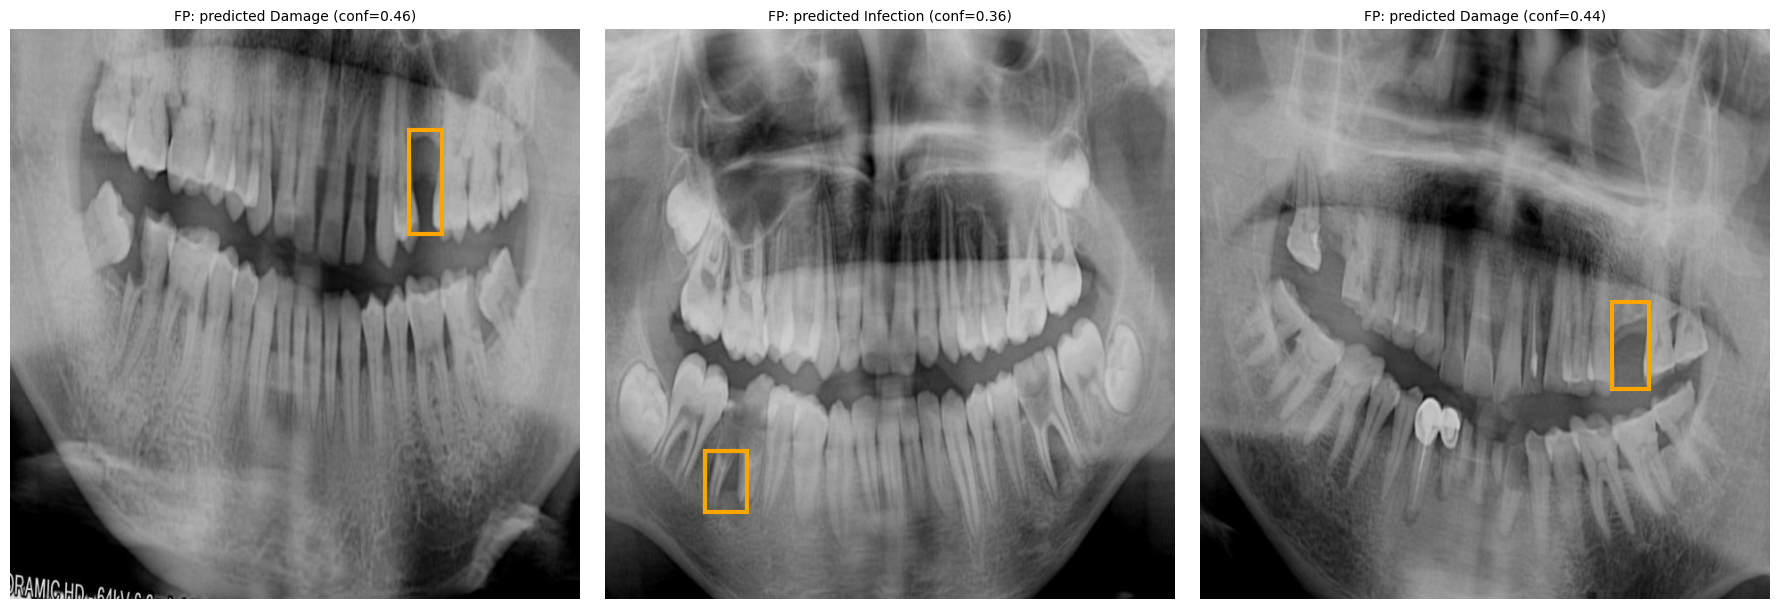

=== Misclassifications ===


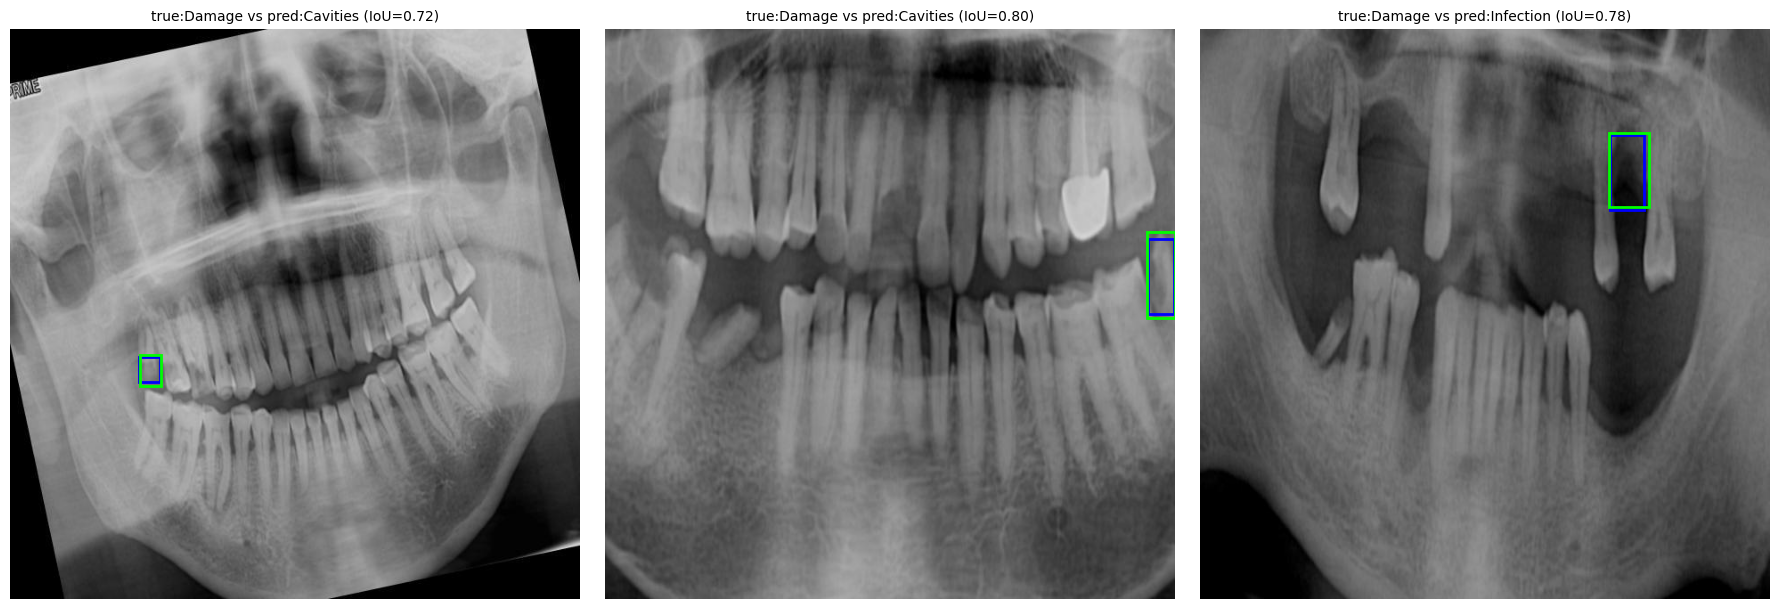

In [12]:
import random, cv2
import matplotlib.pyplot as plt

def show_examples(examples, kind, n=3, seed=1):
    random.seed(seed)
    sampled = random.sample(examples, min(n, len(examples)))
    fig, axes = plt.subplots(1, len(sampled), figsize=(6*len(sampled), 6))
    if len(sampled) == 1:
        axes = [axes]
    for ax, ex in zip(axes, sampled):
        img = cv2.cvtColor(cv2.imread(str(test_img_dir / f"{ex['image_id']}.jpg")), cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        ax.imshow(img)
        if kind == 'FN':
            x_c, y_c, bw, bh = ex['box']
            x1, y1 = (x_c-bw/2)*w, (y_c-bh/2)*h
            ax.add_patch(plt.Rectangle((x1,y1), bw*w, bh*h, fill=False, color='red', linewidth=3))
            ax.set_title(f"FN: missed {ex['true_class']}\narea={bw*w*bh*h:.0f}px²", fontsize=10)
        elif kind == 'FP':
            x_c, y_c, bw, bh = ex['box']
            x1, y1 = (x_c-bw/2)*w, (y_c-bh/2)*h
            ax.add_patch(plt.Rectangle((x1,y1), bw*w, bh*h, fill=False, color='orange', linewidth=3))
            ax.set_title(f"FP: predicted {ex['pred_class']} (conf={ex['conf']:.2f})", fontsize=10)
        elif kind == 'MIS':
            for box, color, label in [(ex['true_box'], 'blue', f"true:{ex['true_class']}"),
                                       (ex['pred_box'], 'lime', f"pred:{ex['pred_class']}")]:
                x_c, y_c, bw, bh = box
                x1, y1 = (x_c-bw/2)*w, (y_c-bh/2)*h
                ax.add_patch(plt.Rectangle((x1,y1), bw*w, bh*h, fill=False, color=color, linewidth=2))
            ax.set_title(f"true:{ex['true_class']} vs pred:{ex['pred_class']} (IoU={ex['iou']:.2f})", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

fn_weak = [e for e in false_negatives if e['true_class'] != 'Wisdom']
fp_weak = [e for e in false_positives if e['pred_class'] != 'Wisdom']

print("=== False Negatives ===")
show_examples(fn_weak, 'FN', n=3)
print("=== False Positives ===")
show_examples(fp_weak, 'FP', n=3)
if misclassifications:
    print("=== Misclassifications ===")
    show_examples(misclassifications, 'MIS', n=min(3, len(misclassifications)))

Finalized failure-pattern summary for Notebook 3

YOLOv12's failure pattern closely mirrors YOLOv10's rather than diverging from it. Per-instance false-negative rates follow the same ordering: Infection highest (63.9%), Damage and Cavities similar (56.8% and 49.7%), Wisdom lowest (7.6%) — nearly identical to YOLOv10's 60.2%/49.9%/49.6%/8.8%. Misclassifications remain rare (30/2,520, ~1.2%) and overwhelmingly concentrated in the same Damage↔Cavities confusion (80% of all misclassifications, vs. 75% for YOLOv10). This cross-architecture consistency suggests the dominant failure mode is driven by genuine visual ambiguity in the dataset itself — Cavities and Damage likely share overlapping visual presentation on an X-ray — rather than a weakness specific to either detector's architecture.

checkpoint record

In [13]:
print("=== Notebook 3 (YOLOv12) — Final Checkpoint ===")
print(f"Best checkpoint: {FULL_RUN_CKPT}")
print(f"\nFinal test-split metrics:")
print(f"  Precision: {precision_final:.3f} | Recall: {recall_final:.3f} | F1: {f1_final:.3f}")
print(f"  mAP@50: {test_results.box.map50:.3f} | mAP@50-95: {test_results.box.map:.3f}")
print(f"  Inference speed: {1000/inference_ms:.1f} FPS")

=== Notebook 3 (YOLOv12) — Final Checkpoint ===
Best checkpoint: /kaggle/input/datasets/farhaanjumnisha/yolov12-checkpoint/yolov12m_dental/full_run/weights/best.pt

Final test-split metrics:
  Precision: 0.655 | Recall: 0.572 | F1: 0.611
  mAP@50: 0.481 | mAP@50-95: 0.226
  Inference speed: 24.4 FPS
